## Práctico 1: Explorando técnicas para clasificación de vinos.

En este práctico se resolverá un problema de clasificación multiclase de distintas formas para fomentar una discusión acerca de qué técnica conviene más dependiendo del caso, además de definir métricas apropiadas para evaluar los modelos. 



### Librerías usadas:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn import datasets
import pandas as pd


En caso de estar usando pip, puede instalarlos con el comando:
```
pip install -r requirements.txt
```
Si usa poetry, el comando es:
```
poetry install
```

# Dataset
Este dataset incluye información sobre tres clases de vinos producidos en Italia y 13 características (features)predictivas. En base a las características se debe predecir la clase de vino (simplemente llamada class_0, class_1 o class_2)

In [2]:
wines = datasets.load_wine()

features = wines.data
labels = wines.target

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.5, random_state=42)

In [3]:
df = pd.DataFrame(features, columns=wines.feature_names)
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Modelos tradicionales de ML

¿Cómo podemos resolver el problema de **clasificación**?

**Algoritmos**:
   - **Random Forest**.
   - **XGBoost**.
   - **Naive Bayes**.
   - **LightGBM** (Gradient boosting).
   - **Voting Classifier**: Combina múltiples modelos y se predice por votación.




# Ejercicio 1:

Entrenar un modelo a elección para resolver el problema de clasificación multiclase.


Recordatorio de algunas funciones básicas que pueden ser útiles:

- model.fit(X_train, y_train)
- model.predict(X_test)

Para evaluación:
- accuracy_score(y_test, predictions)
- f1_score(y_test, predictions, average='weighted')

Se pueden importar modelos (por ejemplo de sklearn).

In [4]:
#Completar
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="multi:softmax",   
    num_class=3,                 
    eval_metric="mlogloss",
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", acc)
print("F1-score:", f1)


Accuracy: 0.898876404494382
F1-score: 0.8994776734617267


## Exploración de datos

En la siguiente celda se estudia la correlación entre las features y el target.

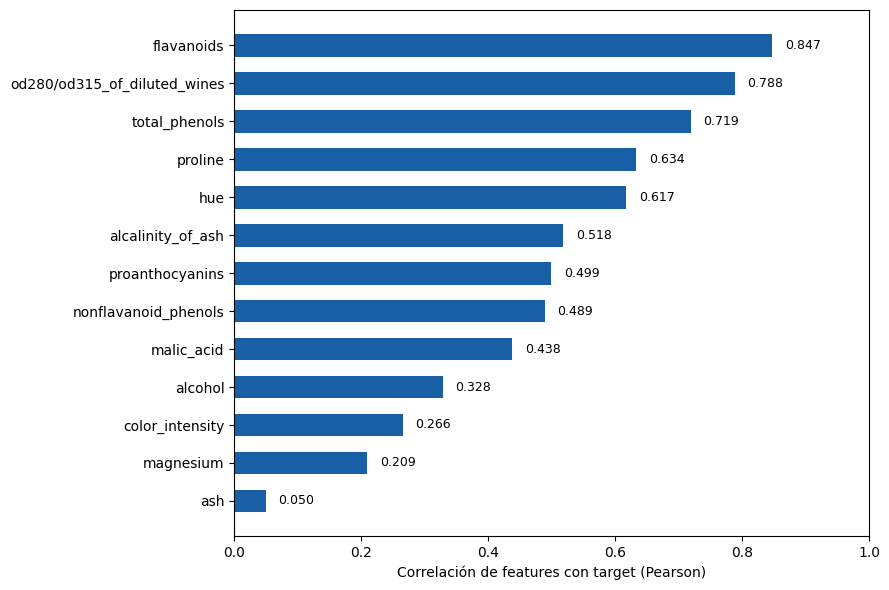

In [5]:
X, y = wines.data, wines.target


corrs = np.array([np.corrcoef(X[:, i], y)[0, 1] for i in range(X.shape[1])])
corrs = np.abs(corrs)

order = np.argsort(np.abs(corrs))[::-1]
sorted_corrs  = corrs[order]
sorted_labels = np.array(wines.feature_names)[order]

colors = ['#185FA5' if c >= 0 else '#A32D2D' for c in sorted_corrs]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(sorted_labels, sorted_corrs, color=colors, height=0.6)

ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel("Correlación de features con target (Pearson)")
ax.set_xlim(0, 1)
ax.invert_yaxis()

for bar, v in zip(bars, sorted_corrs):
    ax.text(v + (0.02), bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
import plotly.express as px
import pandas as pd
from sklearn import datasets

wines = datasets.load_wine()
X, y = wines.data, wines.target

df = pd.DataFrame({
    "Flavanoids":            X[:, 6],
    "OD280/OD315":           X[:, 11],
    "Total phenols":         X[:, 5],
    "Class": [wines.target_names[c] for c in y]
})

fig = px.scatter_3d(
    df,
    x="Flavanoids",
    y="OD280/OD315",
    z="Total phenols",
    color="Class",
    color_discrete_map={
        "class_0": "#185FA5",
        "class_1": "#854F0B",
        "class_2": "#0F6E56",
    },
    symbol="Class",
    opacity=0.85,
    title="Top 3 features — interactive 3D scatter by wine class",
)

fig.update_traces(marker=dict(size=5, line=dict(width=0.3, color="white")))
fig.update_layout(
    legend=dict(title="Wine class"),
    margin=dict(l=0, r=0, t=40, b=0),
    scene=dict(
        xaxis_title="Flavanoids",
        yaxis_title="OD280/OD315",
        zaxis_title="Total phenols",
    )
)

fig.write_html("wine_3d.html", auto_open=True)

<img src="imgs/scatter_plot_features.png" width="80%"/>

## ¿Se puede usar otro enfoque para resolver el problema? 

Observando la gráfica anterior, parece viable hacer un modelo predictor que use los clusters (o cúmulos) formados por las features para poder clasificar.

In [7]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.optimize import linear_sum_assignment
import numpy as np
from sklearn.decomposition import PCA

class KMeansClassifierAdapter(BaseEstimator, ClassifierMixin):
    def __init__(self, n_clusters=3, **kwargs):
        self.n_clusters = n_clusters
        self.kmeans = KMeans(n_clusters=n_clusters, **kwargs)
        self.mapping_ = {}

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n = len(self.classes_)
        cluster_labels = self.kmeans.fit_predict(X)


        cost = np.zeros((n, n))
        for i in range(n): #Los clusters tienen una ID (0, 1 o 2), aquí alineamos esas ID con las tres clases que tiene el dataset
            for j in range(n):
                cost[i, j] = np.sum((y == self.classes_[i]) & (cluster_labels == j))
        _, col_ind = linear_sum_assignment(-cost)
        self.mapping_ = {col_ind[i]: self.classes_[i] for i in range(n)}



        #Tras identificar los clusters de 11 dimensiones, los graficamos. PCA nos permite reducir la dimensionalidad
        pca = PCA(n_components=2)
        X2  = pca.fit_transform(X)
        centroids_2d = pca.transform(self.kmeans.cluster_centers_)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for j in range(n):
            mask = cluster_labels == j
            axes[0].scatter(X2[mask, 0], X2[mask, 1], label=f"Cluster {j}", s=40, alpha=0.7)
        axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                        c="black", marker="X", s=180, zorder=5, label="Centroids")
        axes[0].set_title("KMeans — raw cluster IDs")
        axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
        axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
        axes[0].legend()
        aligned_labels = np.array([self.mapping_[c] for c in cluster_labels])
        for cls in self.classes_:
            mask = aligned_labels == cls
            axes[1].scatter(X2[mask, 0], X2[mask, 1], label=f"Class {cls}", s=40, alpha=0.7)
        axes[1].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                        c="black", marker="X", s=180, zorder=5, label="Centroids")
        axes[1].set_title("KMeans — aligned to true class labels")
        axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
        axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
        axes[1].legend()

        plt.suptitle("KMeans Clustering (PCA projection)", fontweight="bold")
        plt.tight_layout()
        plt.show()
        
        return self

    def predict(self, X):
        cluster_labels = self.kmeans.predict(X)
        return np.array([self.mapping_[c] for c in cluster_labels])

    def predict_proba(self, X):
        distances = self.kmeans.transform(X)       
        ordered = np.zeros_like(distances)
        for cluster_idx, class_idx in self.mapping_.items():
            ordered[:, class_idx] = distances[:, cluster_idx]
        # Obtengo la probabilidad como la distancia al centro del cluster (más cerca = mayor prob)
        inv = 1 / (ordered + 1e-9)
        return inv / inv.sum(axis=1, keepdims=True)

## Ejercicio 2: KMeans
Dado el modelo anterior ya implementado, entrenarlo y obtener métricas de performance.

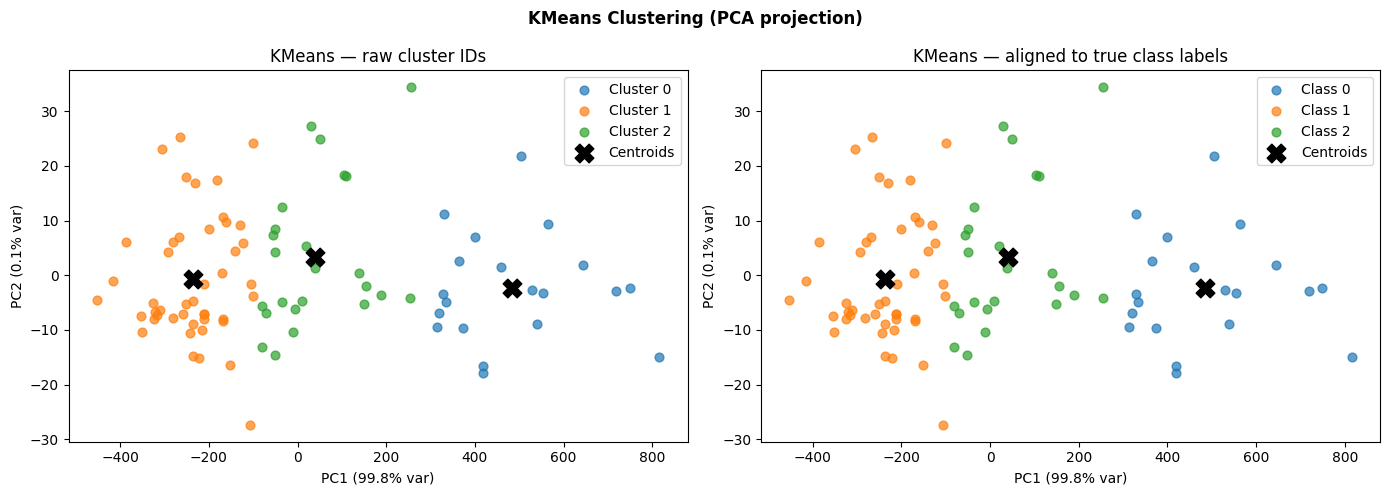

KMeansClassifierAdapter — Accuracy: 0.6067415730337079
KMeansClassifierAdapter — F1-score: 0.6296322770285515


In [8]:
# Completar
model = KMeansClassifierAdapter(n_clusters=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
print("KMeansClassifierAdapter — Accuracy:", acc)
print("KMeansClassifierAdapter — F1-score:", f1)



## Ejercicio 3: Regresión logística
Implementar una regresión logística que permita predecir la variable target. Entrenar el modelo y obtener métricas de performance.

LogisticRegression — Accuracy: 0.9887640449438202
LogisticRegression — F1-score: 0.9888050384780218


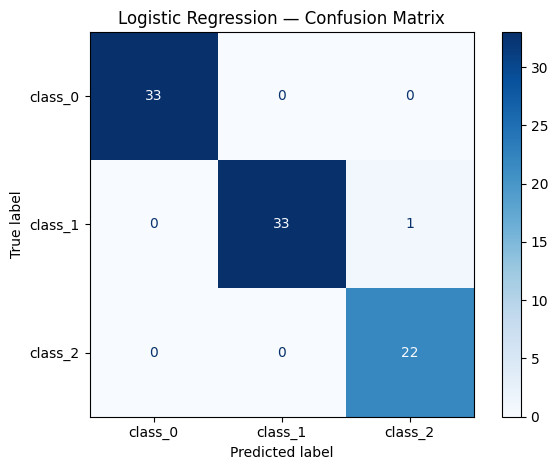

In [13]:
# Completar
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

model_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=42))
])

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print("LogisticRegression — Accuracy:", acc_lr)
print("LogisticRegression — F1-score:", f1_lr)

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wines.target_names)
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()


# Extra: Enfoque de Deep Learning
Podríamos entrenar una red neuronal para resolver el problema, por ejemplo, con un **multi-perceptrón**.

¿Existe una solución que no requiera entrenar? Un **modelo de lenguaje**.




Un modelo de lenguaje no está diseñado particularmente para clasificación, solo devuelve texto en base a una entrada, pero se ha popularizado en la industria el uso de modelos de lenguaje para clasificar imágenes y documentos dada su versatilidad, solo se debe cambiar la prompt para cambiar la tarea (son multi-propósito).

Ejemplo utilizando mistralai/Mistral-7B-Instruct-v0.2 

<img src="imgs/llm_prompt.png" width="80%"/>
<img src="imgs/llm_answer.png" width="50%"/>

<img src="imgs/results_llm.png" width="50%"/>

El código para implementar el modelo es el siguiente. No es parte del práctico replicar los resultados anteriores, esta sección es meramente discursiva.


In [9]:
#from transformers import pipeline
#import torch
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin


class LocalLLMClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, X_train_examples, Y_train_examples, model_name="mistralai/Mistral-7B-Instruct-v0.2", n_examples_per_class=3):
        self.model_name = model_name
        self.n_examples_per_class = n_examples_per_class

        self.classes_ = np.unique(Y_train_examples)
        self.feature_names_ = wines.feature_names

        # Almacenamos ejemplos para agregar a la prompt
        self.examples_ = {}
        for cls in self.classes_:
            cls_indices = np.where(Y_train_examples == cls)[0]
            chosen = cls_indices[:self.n_examples_per_class]
            self.examples_[cls] = X_train_examples[chosen]

        self.pipe_ = pipeline( #Es necesario instalar e importar transformers si desean ejecutar este códiogo
            "text-generation",
            model=self.model_name,
            device=-1
        )

    def fit(self, X, y):
        return self

    def _build_prompt(self, sample):
        """Few-shot prompt, contiene ejemplos de cada clase"""
        lines = ["Based on these examples, predict the class (0, 1 or 2) of the last sample.\n"]
        lines.append("Examples:")

        for cls in self.classes_:
            ex = np.atleast_1d(self.examples_[cls][0])  
            formatted = ", ".join(f"{n}={v:.2f}" for n, v in zip(self.feature_names_, ex))
            lines.append(f"  Sample: [{formatted}] → Class {cls}")
        formatted_x = ", ".join(f"{n}={v:.2f}" for n, v in zip(self.feature_names_, sample))
        lines.append(f"  Last sample: [{formatted_x}] → Class ")

        return "\n".join(lines)

    def _parse_response(self, response_text):
        """Extract the first valid class digit from the LLM output."""
        for char in response_text:
            if char in [str(c) for c in self.classes_]:
                return int(char)
        return int(self.classes_[0])              

    def predict(self, X):
        predictions = []
        for sample in X:
            prompt = self._build_prompt(sample)
            print("Prompt: \n", prompt, "\n")
            output = self.pipe_(
                prompt,
                max_new_tokens=15,               
                do_sample=False,                
                temperature=None,
                top_p=None,
            )
  
            generated = output[0]["generated_text"][len(prompt):]
            print("Answer", generated, "\n")
            pred = self._parse_response(generated)
            predictions.append(pred)

        return np.array(predictions)

    def predict_proba(self, X):
        preds = self.predict(X)
        proba = np.zeros((len(preds), len(self.classes_)))
        for i, p in enumerate(preds):
            proba[i, p] = 1.0
        return proba

# Conclusión

Cada enfoque tiene ventajas y desventajas. Hay que tomar en cuenta:

- Complejidad del modelo.
- Tiempo de entrenamiento.
- Costos de entrenamiento y de inferencia (usar el modelo).
- Mantenibilidad.
- Rendimiento.

Regresión Logística es la mejor opción: datos linealmente separables, interpretable, costo mínimo en producción.

XGBoost funciona bien pero es sobredimensionado(árboles muy complejos) para este dataset chico.

KMeans es frágil en producción debido a su naturaleza no supervisada, la cual no asume targets fijos, llevando a que la alineación cluster↔clase puede romperse con nuevos datos.

LLM es el enfoque de mayor costo/complejidad con peor rendimiento en datos tabulares estructurados. Su valor real es en tareas donde no hay datos etiquetados y se quiere un baseline rápido sin entrenar, o en clasificación de texto/imágenes.